# 01 - 数据浏览与检查

加载采集的 `.npz` 数据，查看多视角图像、深度图、3D 骨架、动作曲线等。

自动适配新旧数据格式（单相机 / 多相机，含/不含深度图和骨架）。

In [24]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider
from IPython.display import display, clear_output
import ipywidgets as widgets

%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

## 1. 选择并加载数据文件

In [25]:
# ---- 修改这里选择数据目录 ----
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'seq_rz_c2_sk')

files = sorted(glob.glob(os.path.join(DATA_DIR, '*.npz')))
if not files:
    raise FileNotFoundError(f'未找到数据文件: {DATA_DIR}')

print(f'找到 {len(files)} 个数据文件:')
for i, f in enumerate(files):
    size_kb = os.path.getsize(f) / 1e3
    print(f'  [{i}] {os.path.basename(f)}  ({size_kb:.1f} KB)')

找到 10 个数据文件:
  [0] seq_000_rz_c2_sk_1778840355.npz  (2337.1 KB)
  [1] seq_001_rz_c2_sk_1778840494.npz  (2315.9 KB)
  [2] seq_002_rz_c2_sk_1778840634.npz  (2314.5 KB)
  [3] seq_003_rz_c2_sk_1778840772.npz  (2345.9 KB)
  [4] seq_004_rz_c2_sk_1778840907.npz  (2250.5 KB)
  [5] seq_005_rz_c2_sk_1778841045.npz  (2294.6 KB)
  [6] seq_006_rz_c2_sk_1778841157.npz  (2333.8 KB)
  [7] seq_007_rz_c2_sk_1778841265.npz  (2342.6 KB)
  [8] seq_008_rz_c2_sk_1778841372.npz  (2279.1 KB)
  [9] seq_009_rz_c2_sk_1778841475.npz  (2319.8 KB)


In [26]:
FILE_INDEX = 5  # -1 表示最新文件，可改为 0, 1, ...

data = np.load(files[FILE_INDEX])
keys = list(data.keys())
print(f'加载: {os.path.basename(files[FILE_INDEX])}')
print(f'键: {keys}')

# ---- 自动检测数据格式 ----
# 多视角新格式: images 为 (N, V, H, W)
# 多视角旧格式: images_front, images_side, ...
# 单视角: images 为 (N, H, W)
def detect_format(data):
    """自动检测 NPZ 数据格式，返回标准化字段。"""
    info = {}

    # 多视角图像
    if 'images' in data and data['images'].ndim == 4:
        info['images'] = data['images']                     # (N, V, H, W)
        info['n_views'] = data['images'].shape[1]
    else:
        # 旧格式或单视角：按 _front/_side/... 后缀拼接
        views = []
        view_names = []
        for suffix in ['front', 'side', 'top', 'back']:
            key = f'images_{suffix}'
            if key in data:
                views.append(data[key])
                view_names.append(suffix)
        if views:
            info['images'] = np.stack(views, axis=1)        # (N, V, H, W)
            info['n_views'] = len(views)
            info['view_names'] = view_names
        elif 'images' in data:
            info['images'] = data['images'][:, None, :, :]  # (N, 1, H, W)
            info['n_views'] = 1
        else:
            raise ValueError("找不到图像数据")

    info['view_names'] = info.get('view_names',
        list(data['view_names'].astype(str)) if 'view_names' in data
        else [f'view_{i}' for i in range(info['n_views'])])

    # 深度图
    if 'depths' in data and data['depths'].ndim == 4:
        info['depths'] = data['depths']                     # (N, V, H, W)
    else:
        dep_views = []
        for suffix in ['front', 'side', 'top', 'back']:
            key = f'depth_maps_{suffix}'
            if key in data:
                dep_views.append(data[key])
        if 'depth_maps' in data:
            info['depths'] = data['depth_maps'][:, None, :, :]
        elif dep_views:
            info['depths'] = np.stack(dep_views, axis=1)

    # 3D 骨架
    if 'positions' in data:
        info['positions'] = data['positions']               # (N, 3, N_nodes)
        info['radii'] = data['radii'] if 'radii' in data else None

    # 动作
    info['actions'] = data['actions']

    # 元数据
    info['dt'] = float(data['dt']) if 'dt' in data else None
    info['focal'] = float(data['focal']) if 'focal' in data else None
    info['H'] = int(data['H']) if 'H' in data else info['images'].shape[2]
    info['W'] = int(data['W']) if 'W' in data else info['images'].shape[3]

    # 相机参数
    if 'camera_params' in data:
        info['camera_params'] = data['camera_params']       # (V, 10)
    else:
        cams = []
        for suffix in ['front', 'side', 'top', 'back']:
            if f'camera_eye_{suffix}' in data:
                cams.append({
                    'eye': data[f'camera_eye_{suffix}'],
                    'center': data[f'camera_center_{suffix}'],
                    'up': data[f'camera_up_{suffix}'],
                })
        if cams:
            info['cameras_legacy'] = cams
        elif 'camera_eye' in data:
            info['cameras_legacy'] = [{
                'eye': data['camera_eye'], 'center': data['camera_center'],
                'up': data['camera_up'],
            }]

    return info

info = detect_format(data)
N = info['images'].shape[0]
V = info['n_views']

print(f'\n=== 数据概览 ===')
print(f'  帧数:     {N}')
print(f'  视角数:   {V} ({", ".join(info["view_names"])})')
print(f'  图像尺寸: {info["H"]}×{info["W"]}')
print(f'  动作维度: {info["actions"].shape[1]}')
print(f'  深度图:   {"有" if "depths" in info else "无"}')
print(f'  3D骨架:   {"有" if "positions" in info else "无"}')
print(f'  相机参数: {"有(camera_params)" if "camera_params" in info else "有(legacy)" if "cameras_legacy" in info else "无"}')
if info['dt']:
    print(f'  采样间隔: {info["dt"]:.4f} s')

加载: seq_005_rz_c2_sk_1778841045.npz
键: ['images', 'actions', 'dt', 'focal', 'H', 'W', 'camera_params', 'view_names', 'positions', 'radii', 'depths', 'images_front', 'camera_eye_front', 'camera_center_front', 'camera_up_front', 'images_side', 'camera_eye_side', 'camera_center_side', 'camera_up_side', 'depth_maps_front', 'depth_maps_side']



=== 数据概览 ===
  帧数:     500
  视角数:   2 (primary, side_60)
  图像尺寸: 100×100
  动作维度: 2
  深度图:   有
  3D骨架:   有
  相机参数: 有(camera_params)
  采样间隔: 0.0050 s


## 2. 全局动作曲线

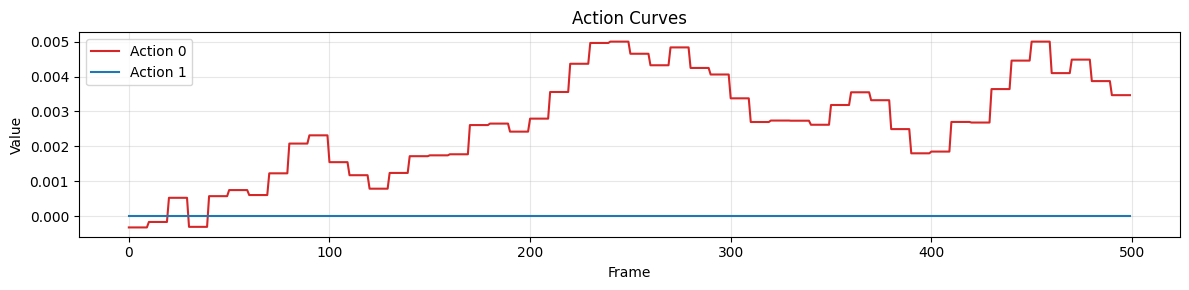

In [27]:
fig, ax = plt.subplots(figsize=(12, 3))
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']
actions = info['actions']
for d in range(actions.shape[1]):
    ax.plot(actions[:, d], color=colors[d % len(colors)], label=f'Action {d}')
ax.set_xlabel('Frame')
ax.set_ylabel('Value')
ax.set_title('Action Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 逐帧浏览（交互式滑块）

IntSlider(value=0, description='Frame', max=499)

Output()

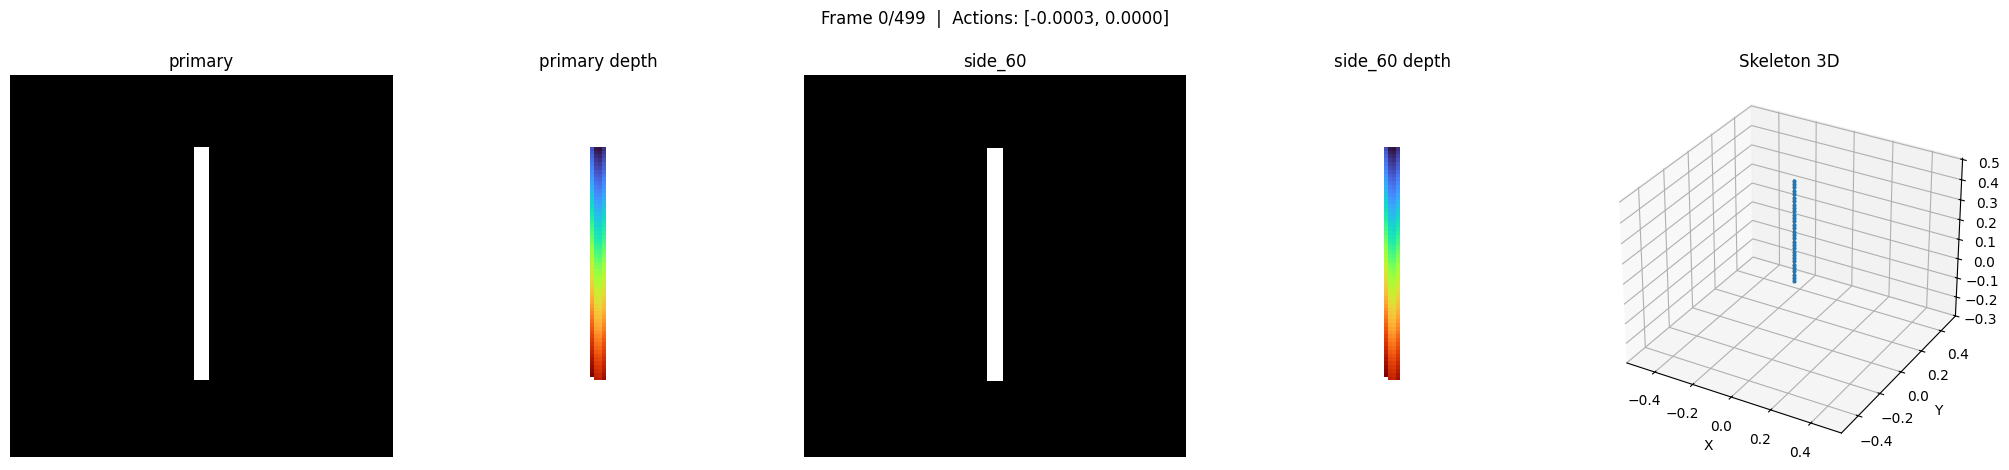

In [28]:
# ---- 交互式多视角 + 深度浏览 ----
images_all = info['images']   # (N, V, H, W)
depths_all = info.get('depths')  # (N, V, H, W) or None
has_depth = depths_all is not None
has_sk = 'positions' in info

# 计算 3D 骨架轴范围（全局，X/Y 以 0 为中心对称）
if has_sk:
    _ap = info['positions'].reshape(3, -1)
    _xy_max = max(np.abs(_ap[0]).max(), np.abs(_ap[1]).max()) * 1.1
    _z_min, _z_max = _ap[2].min(), _ap[2].max()
    _z_margin = (_z_max - _z_min) * 0.05
    sk_xlim = (-_xy_max, _xy_max)
    sk_ylim = (-_xy_max, _xy_max)
    sk_zlim = (_z_min - _z_margin, _z_max + _z_margin)

# 计算子图列数: 每视角一张图像 + (可选)每视角一张深度 + (可选)1张骨架3D
ncols = V * (2 if has_depth else 1) + (1 if has_sk else 0)

slider = widgets.IntSlider(min=0, max=N-1, step=1, value=0, description='Frame')
out = widgets.Output()

def show_frame(frame_idx):
    fig = plt.figure(figsize=(4 * ncols, 5))

    col = 0
    for v in range(V):
        # 图像
        ax = fig.add_subplot(1, ncols, col + 1)
        ax.imshow(images_all[frame_idx, v], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{info["view_names"][v]}')
        ax.axis('off')
        col += 1

        # 深度图
        if has_depth:
            ax = fig.add_subplot(1, ncols, col + 1)
            dep = depths_all[frame_idx, v]
            dep_masked = np.ma.masked_where(dep == 0, dep)
            ax.imshow(dep_masked, cmap='turbo')
            ax.set_title(f'{info["view_names"][v]} depth')
            ax.axis('off')
            col += 1

    # 3D 骨架
    if has_sk:
        ax = fig.add_subplot(1, ncols, col + 1, projection='3d')
        pos = info['positions'][frame_idx]  # (3, N_nodes)
        ax.plot(pos[0], pos[1], pos[2], 'o-', markersize=2, linewidth=1.5)
        ax.set_title('Skeleton 3D')
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.set_xlim(*sk_xlim); ax.set_ylim(*sk_ylim); ax.set_zlim(*sk_zlim)

    act_str = ', '.join([f'{v:.4f}' for v in actions[frame_idx]])
    fig.suptitle(f'Frame {frame_idx}/{N-1}  |  Actions: [{act_str}]', fontsize=12)
    plt.tight_layout()
    plt.show()

def on_slider_change(change):
    with out:
        clear_output(wait=True)
        show_frame(slider.value)

slider.observe(on_slider_change, names='value')
display(slider, out)
show_frame(0)

## 4. 网格预览（多帧一览）

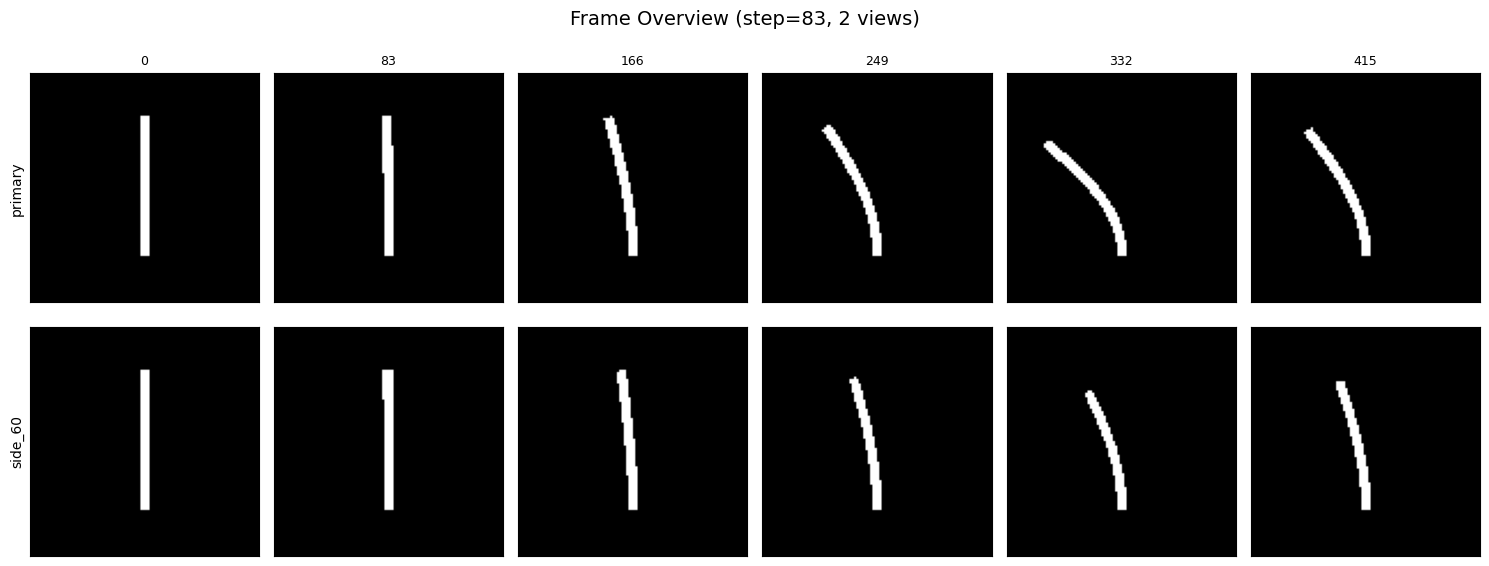

In [29]:
N_COLS = 6
N_ROWS = V  # 每行一个视角
N_SHOW = N_COLS
step = max(1, N // N_SHOW)
indices = list(range(0, N, step))[:N_SHOW]

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 3 * N_ROWS))
if N_ROWS == 1:
    axes = axes[None, :]  # 保证二维
for v in range(V):
    for c, idx in enumerate(indices):
        axes[v, c].imshow(images_all[idx, v], cmap='gray', vmin=0, vmax=1)
        if v == 0:
            axes[v, c].set_title(f'{idx}', fontsize=9)
        if c == 0:
            axes[v, c].set_ylabel(info['view_names'][v], fontsize=10)
        axes[v, c].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.suptitle(f'Frame Overview (step={step}, {V} views)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. 图像值分布 & 深度统计

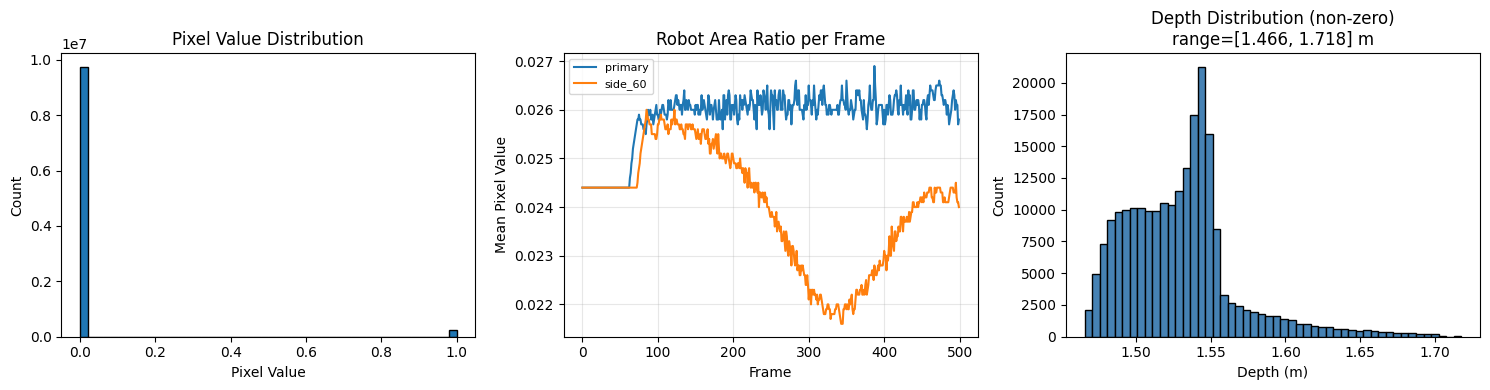

In [30]:
fig, axes = plt.subplots(1, 2 + (1 if has_depth else 0), figsize=(5 * (2 + (1 if has_depth else 0)), 4))

# 像素值直方图
axes[0].hist(images_all.flatten(), bins=50, edgecolor='black')
axes[0].set_title('Pixel Value Distribution')
axes[0].set_xlabel('Pixel Value'); axes[0].set_ylabel('Count')

# 每帧机器人占比（按视角）
for v in range(V):
    ratio = images_all[:, v].mean(axis=(1, 2))
    axes[1].plot(ratio, label=info['view_names'][v])
axes[1].set_title('Robot Area Ratio per Frame')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Mean Pixel Value')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# 深度统计
if has_depth:
    valid_depths = depths_all[depths_all > 0]
    if len(valid_depths) > 0:
        axes[2].hist(valid_depths, bins=50, edgecolor='black', color='steelblue')
        axes[2].set_title(f'Depth Distribution (non-zero)\nrange=[{valid_depths.min():.3f}, {valid_depths.max():.3f}] m')
        axes[2].set_xlabel('Depth (m)'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. 3D 骨架序列（如果数据含 positions）

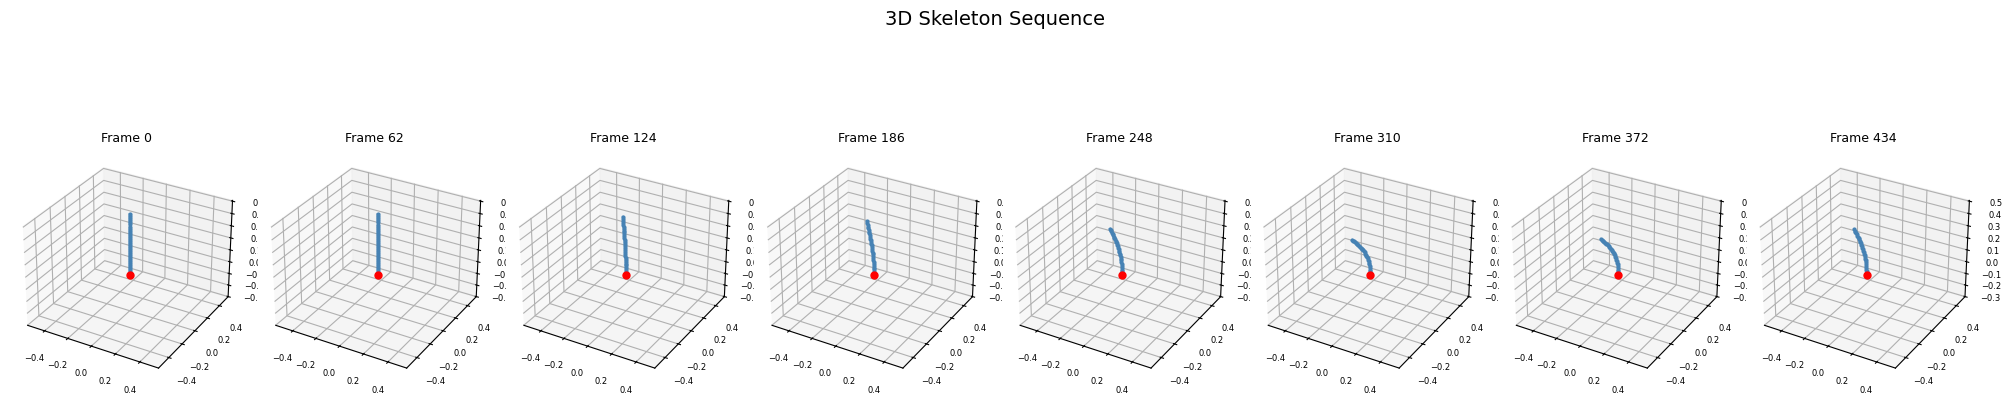

In [31]:
if 'positions' in info:
    positions = info['positions']  # (N, 3, N_nodes)
    
    # 选取若干帧展示骨架演变
    N_SK = 8
    sk_step = max(1, N // N_SK)
    sk_indices = list(range(0, N, sk_step))[:N_SK]
    
    # X/Y 以 0 为中心对称，Z 完整范围
    all_pos = positions.reshape(3, -1)
    xy_max = max(np.abs(all_pos[0]).max(), np.abs(all_pos[1]).max()) * 1.1
    z_min, z_max = all_pos[2].min(), all_pos[2].max()
    z_margin = (z_max - z_min) * 0.05
    
    fig = plt.figure(figsize=(20, 5))
    for i, idx in enumerate(sk_indices):
        ax = fig.add_subplot(1, N_SK, i + 1, projection='3d')
        pos = positions[idx]
        ax.plot(pos[0], pos[1], pos[2], 'o-', color='steelblue', markersize=2, linewidth=1.5)
        ax.plot(pos[0, 0], pos[1, 0], pos[2, 0], 'ro', markersize=5)  # 固定端(红色)
        ax.set_xlim(-xy_max, xy_max)
        ax.set_ylim(-xy_max, xy_max)
        ax.set_zlim(z_min - z_margin, z_max + z_margin)
        ax.set_title(f'Frame {idx}', fontsize=9)
        ax.tick_params(labelsize=6)
    
    plt.suptitle('3D Skeleton Sequence', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('当前数据不含 positions（需要用 --sk 参数采集）')

## 7. 相机布局（3D 俯视图）

/tmp/ipykernel_4192084/65193350.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


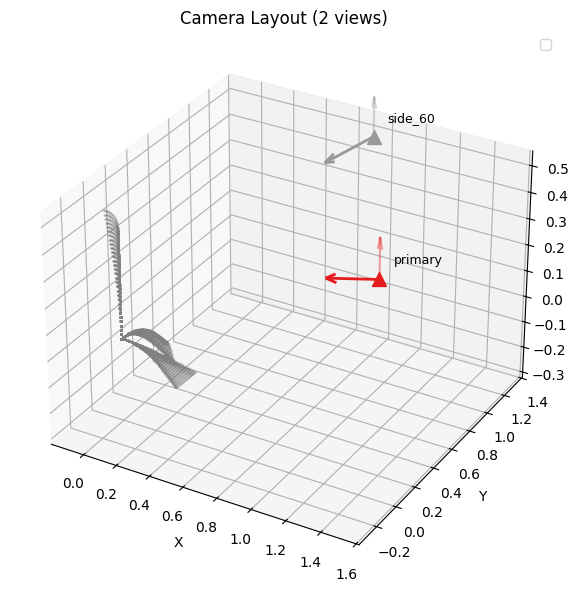

In [32]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 绘制相机位置和朝向
cam_colors = plt.cm.Set1(np.linspace(0, 1, max(V, 1)))

if 'camera_params' in info:
    for v in range(V):
        p = info['camera_params'][v]
        eye, center, up = p[:3], p[3:6], p[6:9]
        # 相机位置
        ax.scatter(*eye, s=100, c=[cam_colors[v]], marker='^', zorder=5)
        # 视线方向
        d = center - eye
        d = d / np.linalg.norm(d) * 0.3
        ax.quiver(*eye, *d, color=cam_colors[v], arrow_length_ratio=0.2, linewidth=2)
        ax.text(*(eye + 0.05), info['view_names'][v], fontsize=9)
        # up 方向
        ax.quiver(*eye, *(up / np.linalg.norm(up) * 0.15),
                  color=cam_colors[v], alpha=0.4, arrow_length_ratio=0.3)
elif 'cameras_legacy' in info:
    for v, cam in enumerate(info['cameras_legacy']):
        eye = np.array(cam['eye'])
        center = np.array(cam['center'])
        up = np.array(cam['up'])
        ax.scatter(*eye, s=100, c=[cam_colors[v]], marker='^', zorder=5)
        d = center - eye
        d = d / np.linalg.norm(d) * 0.3
        ax.quiver(*eye, *d, color=cam_colors[v], arrow_length_ratio=0.2, linewidth=2)
        ax.text(*(eye + 0.05), info['view_names'][v], fontsize=9)

# 绘制杆体大致范围（如果有骨架数据）
if 'positions' in info:
    all_pos = info['positions'].reshape(3, -1)
    ax.plot(all_pos[0], all_pos[1], all_pos[2], '.', alpha=0.1, color='gray', markersize=1)
else:
    # 标记中心点
    ax.scatter(0, 0, 0.25, s=50, c='red', marker='o', label='Center')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'Camera Layout ({V} views)')
ax.legend()
plt.tight_layout()
plt.show()